In [1]:
!pip install numpy
!pip install gymnasium[box2d]
!pip install matplotlib


In [2]:
import numpy as np
import random
import gymnasium as gym

In [ ]:
print("Hello")

In [107]:

# 0=up,1=right,2=down,3=left
class Agent():
        def __init__(self,epsilon,decayr,lr):
            self.epsilon=epsilon
            self.decayr=decayr
            self.lr=lr
            self.q_table = np.zeros((37, 4))

        def get_action_train(self,state):
            if random.random() < self.epsilon :
                return random.randint(0, 3)
            else:
                max_val=np.max(self.q_table[state])
                max_indices = np.flatnonzero(self.q_table[state] == max_val) 
                return np.random.choice(max_indices)
            
        def get_action_true(self,state):
            max_val=np.max(self.q_table[state])
            max_indices = np.flatnonzero(self.q_table[state] == max_val) 
            return np.random.choice(max_indices)
        
        def update_q_table (self,state,next_state, action,reward):
            if next_state == 47:
                self.q_table[state,action]=self.lr*(500 + reward) + (1-self.lr)*self.q_table[state,action]
            else:
                self.q_table[state,action]=self.lr*(self.q_table[next_state,action] + reward) + (1-self.lr)*self.q_table[state,action]
    
        def train_agent(self,episodes):
            env = gym.make("CliffWalking-v1", max_episode_steps=500)
            observation, info = env.reset()
            
            # Reset the environment to generate the first observation
            
            reward_per_ep=[]
            total_reward_per_ep=0
            while episodes :
                # this is where you would insert your policy
                action = self.get_action_train(observation)
                
                # step (transition) through the environment with the action
                # receiving the next observation, reward and if the episode has terminated or truncated
                new_observation, reward, terminated, truncated, info = env.step(action)
                total_reward_per_ep+=reward
                self.update_q_table(observation,new_observation,action,reward)
                observation=new_observation
                '''
                if reward !=-1 :
                    print (reward,observation)
                '''
                # If the episode has ended then we can reset to start a new episode
                if terminated or truncated:
                    observation, info = env.reset()
                    episodes-=1
                    if self.epsilon*self.decayr>0.01:
                        self.epsilon*=self.decayr
                    if terminated :
                        total_reward_per_ep+=500
                    reward_per_ep.append(total_reward_per_ep)
                    total_reward_per_ep=0


            env.close()
            return reward_per_ep
        def test_agent(self,episodes):
            env = gym.make("CliffWalking-v1" ,max_episode_steps=500)
            observation, info = env.reset()
            # Reset the environment to generate the first observation
            reward_per_ep=[]
            total_reward_per_ep=0
            while episodes :
                # this is where you would insert your policy
                action = self.get_action_true(observation)
                # step (transition) through the environment with the action
                # receiving the next observation, reward and if the episode has terminated or truncated
                observation, reward, terminated, truncated, info = env.step(action)
                total_reward_per_ep+=reward
                '''
                if reward !=-1 :
                    print (reward,observation)
                '''
                # If the episode has ended then we can reset to start a new episode
                if terminated or truncated:
                    observation, info = env.reset()
                    episodes-=1
                    if terminated :
                        total_reward_per_ep+=500
                    reward_per_ep.append(total_reward_per_ep)
                    total_reward_per_ep=0

            env.close()
            return reward_per_ep

In [108]:
import matplotlib.pyplot as plt
model1=Agent(epsilon=0.5,decayr=1,lr=0.1)
model2=Agent(epsilon=0.05,decayr=1,lr=0.1)
model3=Agent(epsilon=1,decayr=0.9,lr=0.1)

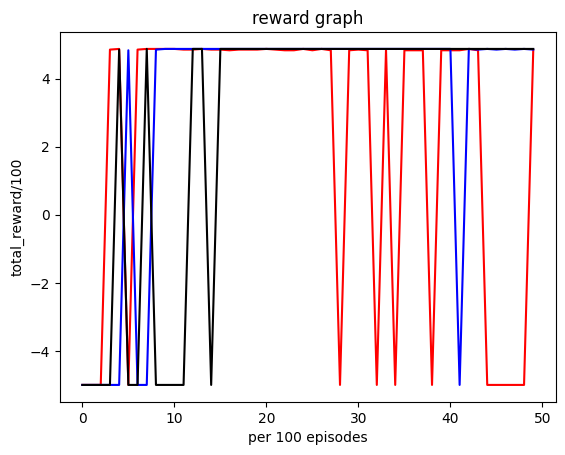

In [109]:
import statistics

l=[]
l1=[]
l2=[]
for i in range(50):
    model1.train_agent(30)
    result=model1.test_agent(10)
    l.append(statistics.mean(result)/100)
for i in range(50):
    model2.train_agent(30)
    result1=model2.test_agent(10)
    l1.append(statistics.mean(result1)/100)
for i in range(50):
    model3.train_agent(30)
    result2=model3.test_agent(10)
    l2.append(statistics.mean(result2)/100)

plt.plot(l,color="red")
plt.plot(l1,color="blue")
plt.plot(l2,color="black")
plt.xlabel("per 100 episodes")
plt.ylabel("total_reward/100")
plt.title("reward graph")
plt.show()


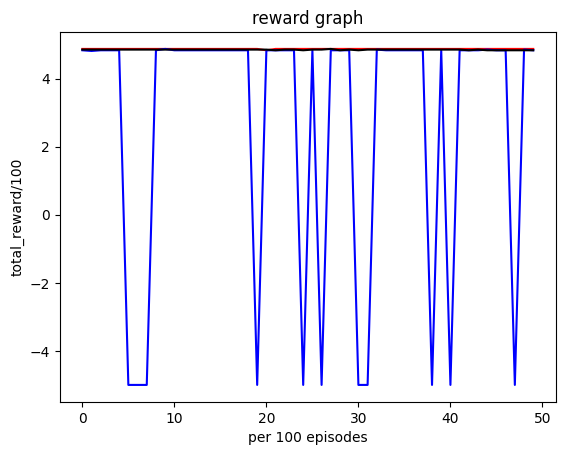

In [116]:
l=[]
l1=[]
l2=[]
for i in range(50):
    model1.train_agent(30)
    result=model1.test_agent(10)
    l.append(statistics.mean(result)/100)
for i in range(50):
    model2.train_agent(30)
    result1=model2.test_agent(10)
    l1.append(statistics.mean(result1)/100)
for i in range(50):
    model3.train_agent(30)
    result2=model3.test_agent(10)
    l2.append(statistics.mean(result2)/100)

plt.plot(l,color="red")
plt.plot(l1,color="blue")
plt.plot(l2,color="black")
plt.xlabel("per 100 episodes")
plt.ylabel("total_reward/100")
plt.title("reward graph")
plt.show()
